# EDA ราคาค่าเช่า (Rental Price)

Notebook นี้ใช้สำรวจข้อมูลราคาค่าเช่าก่อนนำไปสร้าง Feature และโมเดลทำนายราคา

เป้าหมายหลัก:

1. ทำความเข้าใจข้อมูลสัญญาเช่า ห้อง และโครงการ
2. ตรวจ Missing Value และข้อมูลซ้ำ
3. ดูการกระจายและค่าผิดปกติของราคาค่าเช่า
4. สำรวจปัจจัยที่อาจสัมพันธ์กับราคาค่าเช่า
5. แบ่งข้อมูลเป็น Train, Validation และ Test ตามเวลา

Target ที่ต้องการทำนายคือ `rent`

## 1. Import เครื่องมือ

- `pandas` ใช้จัดการข้อมูลแบบตาราง
- `matplotlib` และ `seaborn` ใช้สร้างกราฟ
- `load_all_data` ใช้โหลดข้อมูลที่ทีมเตรียมไว้
- `chronological_split` ใช้แบ่งข้อมูลตามเวลา

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

from kaverentai.data.load_data import load_all_data
from kaverentai.data.split_data import chronological_split

thai_font_path = r"C:\Windows\Fonts\tahoma.ttf"
font_manager.fontManager.addfont(thai_font_path)
thai_font_name = font_manager.FontProperties(fname=thai_font_path).get_name()

sns.set_theme(style="whitegrid", font=thai_font_name)
plt.rcParams["font.family"] = thai_font_name
plt.rcParams["axes.unicode_minus"] = False

print("ฟอนต์ที่ใช้:", thai_font_name)

ฟอนต์ที่ใช้: Tahoma


## 2. โหลดข้อมูล

ใช้ข้อมูลจาก `data/processed/` ซึ่งผ่านการทำความสะอาดเบื้องต้นแล้ว

ตารางที่ใช้ใน Notebook นี้:

- `leases` มีราคาค่าเช่าและรายละเอียดสัญญา
- `units` มีรายละเอียดห้อง
- `projects` มีรายละเอียดโครงการ

In [2]:
data = load_all_data(cleaned=True)

leases = data["leases"].copy()
units = data["units"].copy()
projects = data["projects"].copy()

print("จำนวนข้อมูลสัญญาเช่า:", len(leases))
print("จำนวนข้อมูลห้อง:", len(units))
print("จำนวนโครงการ:", len(projects))

จำนวนข้อมูลสัญญาเช่า: 50965
จำนวนข้อมูลห้อง: 15367
จำนวนโครงการ: 19


### ดูตัวอย่างข้อมูลแต่ละตาราง

เริ่มจากดูชื่อคอลัมน์และตัวอย่างข้อมูล เพื่อทำความเข้าใจว่าตารางแต่ละชุดเก็บข้อมูลอะไร

In [3]:
leases.head()

,lease_id,unit_id,project_id,tenant_segment,week_start,date_start,week_end,lease_months,rent,is_renewal
0,L000001,U000385,0,year2_3,0,2023-01-03,48,12,9830.0,False
1,L000002,U000055,0,year1,0,2023-01-03,24,6,9820.0,False
2,L000003,U000474,0,year2_3,0,2023-01-03,24,6,8670.0,False
3,L000004,U000167,0,firstjob,0,2023-01-03,24,6,9090.0,False
4,L000005,U000003,0,year4,0,2023-01-03,48,12,9040.0,False


In [4]:
units.head()

,unit_id,project_id,floor,size_sqm,room_type,view,furnished,agent_id
0,U000000,0,8,23.9,studio,standard,True,AG04
1,U000001,0,6,23.0,studio,standard,True,AG05
2,U000002,0,2,25.7,studio,city,True,AG04
3,U000003,0,1,25.8,studio,standard,True,AG01
4,U000004,0,1,39.6,1BR Plus,pool,False,AG05


In [5]:
projects.head()

,project_id,project_name,university,distance_to_campus_m,total_units,year_completed,facility_count
0,0,Kave Condo,ม.กรุงเทพ,100,589,2018,20
1,1,Kave Town Space,ม.กรุงเทพ,200,1073,2020,30
2,2,Kave Town Shift,ม.กรุงเทพ,200,1073,2020,30
3,3,Kave Town Island,ม.กรุงเทพ,300,1770,2023,45
4,4,Kave Town Colony,ม.กรุงเทพ,300,1083,2023,40


## 3. รวมข้อมูลสำหรับวิเคราะห์ราคา

ตาราง `leases` มีราคาค่าเช่า แต่ยังไม่มีรายละเอียดห้องและโครงการ จึงต้องนำตารางมารวมกัน

- เชื่อม `leases` กับ `units` ด้วย `unit_id`
- เชื่อมผลลัพธ์กับ `projects` ด้วย `project_id`
- ใช้ `how="left"` เพื่อเก็บสัญญาเช่าทุกแถวไว้

In [6]:
unit_columns = [
    "unit_id",
    "floor",
    "size_sqm",
    "room_type",
    "view",
    "furnished",
]

rental_data = leases.merge(
    units[unit_columns],
    on="unit_id",
    how="left",
)

project_columns = [
    "project_id",
    "project_name",
    "university",
    "distance_to_campus_m",
    "facility_count",
]

rental_data = rental_data.merge(
    projects[project_columns],
    on="project_id",
    how="left",
)

print("จำนวนแถวก่อนรวมตาราง:", len(leases))
print("จำนวนแถวหลังรวมตาราง:", len(rental_data))

rental_data.head()

จำนวนแถวก่อนรวมตาราง: 50965
จำนวนแถวหลังรวมตาราง: 50965


,lease_id,unit_id,project_id,tenant_segment,week_start,date_start,week_end,lease_months,rent,is_renewal,floor,size_sqm,room_type,view,furnished,project_name,university,distance_to_campus_m,facility_count
0,L000001,U000385,0,year2_3,0,2023-01-03,48,12,9830.0,False,7,25.8,studio,city,True,Kave Condo,ม.กรุงเทพ,100,20
1,L000002,U000055,0,year1,0,2023-01-03,24,6,9820.0,False,8,26.2,studio,pool,True,Kave Condo,ม.กรุงเทพ,100,20
2,L000003,U000474,0,year2_3,0,2023-01-03,24,6,8670.0,False,1,21.4,studio,standard,True,Kave Condo,ม.กรุงเทพ,100,20
3,L000004,U000167,0,firstjob,0,2023-01-03,24,6,9090.0,False,6,24.0,studio,standard,True,Kave Condo,ม.กรุงเทพ,100,20
4,L000005,U000003,0,year4,0,2023-01-03,48,12,9040.0,False,1,25.8,studio,standard,True,Kave Condo,ม.กรุงเทพ,100,20


### แบ่งข้อมูลก่อนทำ EDA

แบ่งข้อมูลตามเวลาก่อน แล้วใช้เฉพาะ `train` สำหรับสำรวจความสัมพันธ์และเลือก Feature เพื่อไม่ให้เห็นข้อมูล Validation และ Test ล่วงหน้า

In [7]:
rental_data["date_start"] = pd.to_datetime(rental_data["date_start"])

train, validation, test = chronological_split(
    rental_data,
    date_column="date_start",
)

eda_data = train.copy()

print("ข้อมูลสำหรับทำ EDA:", len(eda_data), "แถว")

ข้อมูลสำหรับทำ EDA: 40580 แถว


## 4. ตรวจสอบคุณภาพข้อมูลเบื้องต้น

ตรวจจำนวนแถว ชนิดข้อมูล Missing Value และรหัสสัญญาที่ซ้ำ ก่อนเริ่มวิเคราะห์ราคา

In [8]:
print("จำนวนแถว:", rental_data.shape[0])
print("จำนวนคอลัมน์:", rental_data.shape[1])

rental_data.info()

จำนวนแถว: 50965
จำนวนคอลัมน์: 19
<class 'pandas.DataFrame'>
RangeIndex: 50965 entries, 0 to 50964
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   lease_id              50965 non-null  str           
 1   unit_id               50965 non-null  str           
 2   project_id            50965 non-null  int64         
 3   tenant_segment        50965 non-null  str           
 4   week_start            50965 non-null  int64         
 5   date_start            50965 non-null  datetime64[us]
 6   week_end              50965 non-null  int64         
 7   lease_months          50965 non-null  int64         
 8   rent                  50965 non-null  float64       
 9   is_renewal            50965 non-null  bool          
 10  floor                 50965 non-null  int64         
 11  size_sqm              50965 non-null  float64       
 12  room_type             50965 non-null  str           

In [9]:
missing_values = rental_data.isnull().sum()
missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("ไม่พบ Missing Value")
else:
    print(missing_values)

ไม่พบ Missing Value


In [10]:
duplicate_count = rental_data["lease_id"].duplicated().sum()

print("จำนวน lease_id ที่ซ้ำ:", duplicate_count)

จำนวน lease_id ที่ซ้ำ: 0


## 5. สำรวจราคาค่าเช่า

เริ่มจากดูค่าสถิติพื้นฐาน การกระจายของราคา และค่าที่อาจผิดปกติ

In [11]:
eda_data["rent"].describe()

count    40580.000000
mean     11171.930508
std       2119.464185
min       5510.000000
25%       9740.000000
50%      10850.000000
75%      12430.000000
max      21200.000000
Name: rent, dtype: float64

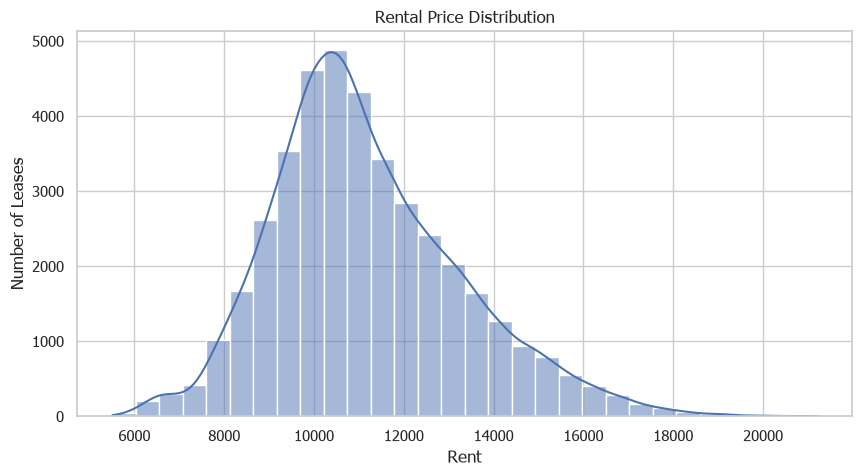

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=eda_data,
    x="rent",
    bins=30,
    kde=True,
)

plt.title("Rental Price Distribution")
plt.xlabel("Rent")
plt.ylabel("Number of Leases")
plt.show()

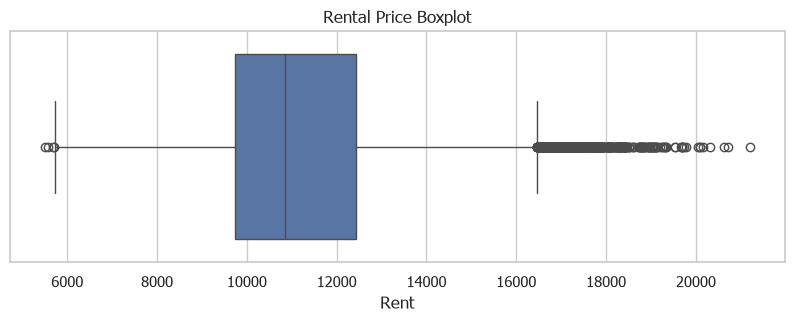

In [13]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=eda_data,
    x="rent",
)

plt.title("Rental Price Boxplot")
plt.xlabel("Rent")
plt.show()

### Correlation Matrix

ใช้ตรวจความสัมพันธ์เชิงเส้นระหว่างตัวแปรตัวเลขกับ `rent` และดูว่าตัวแปรใดสัมพันธ์กันเองมากเกินไป

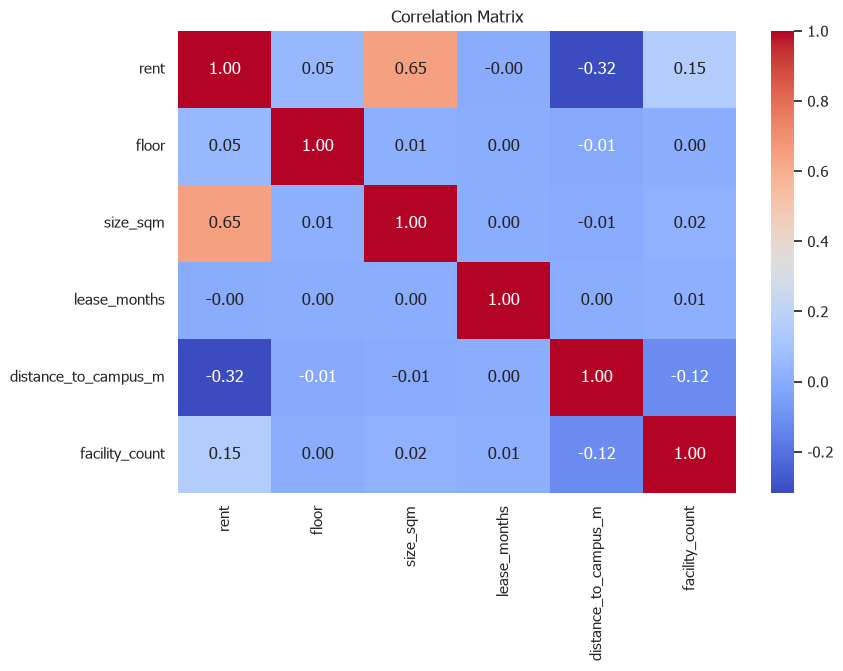

In [14]:
numeric_columns = [
    "rent",
    "floor",
    "size_sqm",
    "lease_months",
    "distance_to_campus_m",
    "facility_count",
]

correlation = eda_data[numeric_columns].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Matrix")
plt.show()

จากกราฟให้สังเกตว่าราคาส่วนใหญ่อยู่ช่วงใด การกระจายเอียงหรือไม่ และมีราคาที่สูงหรือต่ำกว่ากลุ่มทั่วไปหรือไม่ จุดที่อยู่นอก Boxplot ยังไม่ควรถูกลบทันที เพราะอาจเป็นห้องที่มีคุณสมบัติแตกต่างจากห้องทั่วไป

## 6. สำรวจปัจจัยที่อาจสัมพันธ์กับราคา

ในขั้นนี้จะดูประเภทห้อง ขนาดห้อง และการต่อสัญญา เพื่อหาตัวแปรที่อาจมีประโยชน์ต่อโมเดล

In [15]:
print("จำนวนข้อมูลในแต่ละประเภทห้อง")
print(eda_data["room_type"].value_counts())

print("\nค่ามัธยฐานของราคาตามประเภทห้อง")
rent_by_room_type = eda_data.groupby("room_type")["rent"].median()
print(rent_by_room_type.sort_values())

จำนวนข้อมูลในแต่ละประเภทห้อง
room_type
studio      23823
1BR         12825
1BR Plus     3932
Name: count, dtype: int64

ค่ามัธยฐานของราคาตามประเภทห้อง
room_type
studio      10070.0
1BR         12330.0
1BR Plus    14530.0
Name: rent, dtype: float64


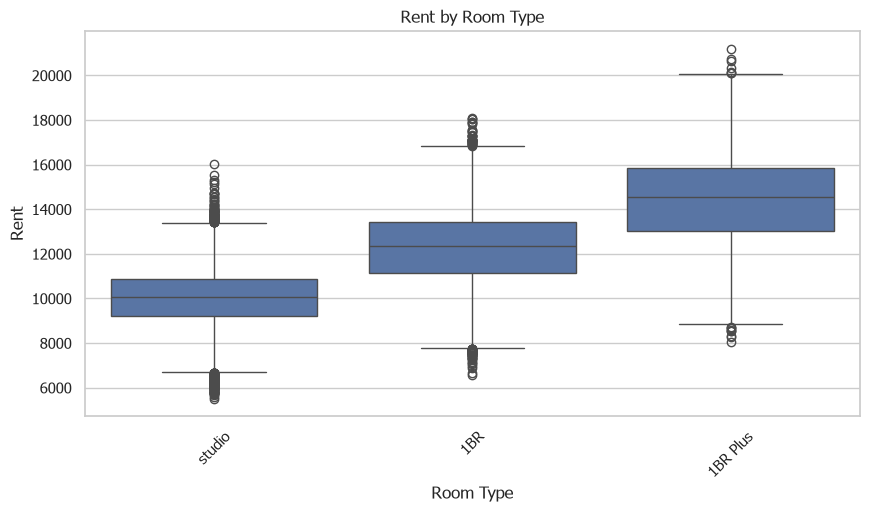

In [16]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=eda_data,
    x="room_type",
    y="rent",
)

plt.title("Rent by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Rent")
plt.xticks(rotation=45)
plt.show()

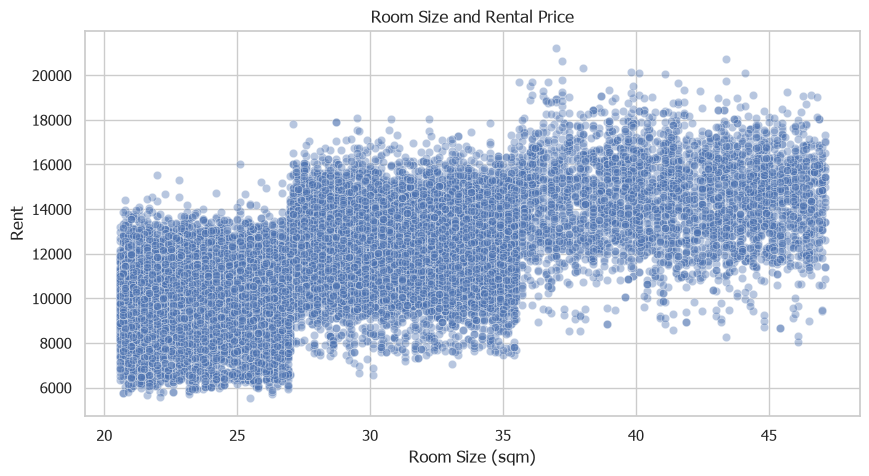

In [17]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=eda_data,
    x="size_sqm",
    y="rent",
    alpha=0.4,
)

plt.title("Room Size and Rental Price")
plt.xlabel("Room Size (sqm)")
plt.ylabel("Rent")
plt.show()

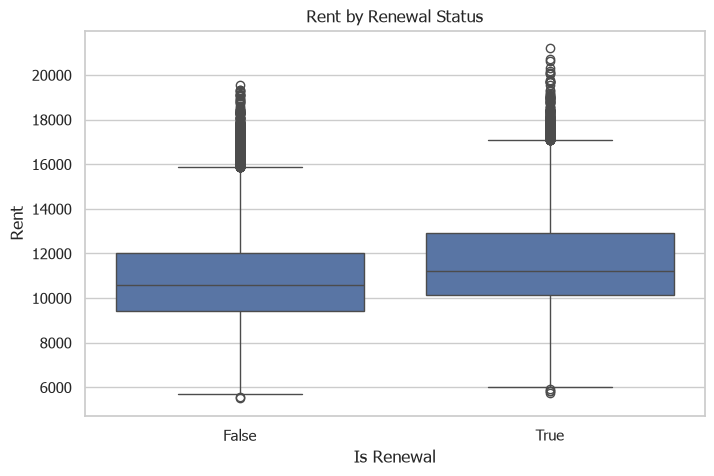

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_data,
    x="is_renewal",
    y="rent",
)

plt.title("Rent by Renewal Status")
plt.xlabel("Is Renewal")
plt.ylabel("Rent")
plt.show()

### วิเคราะห์ตัวแปรประเภทกลุ่มเพิ่มเติม

Correlation Matrix ไม่สามารถอธิบายตัวแปรข้อความได้ จึงเปรียบเทียบราคาตาม `view`, `furnished`, `project_name` และ `university` แยกต่างหาก

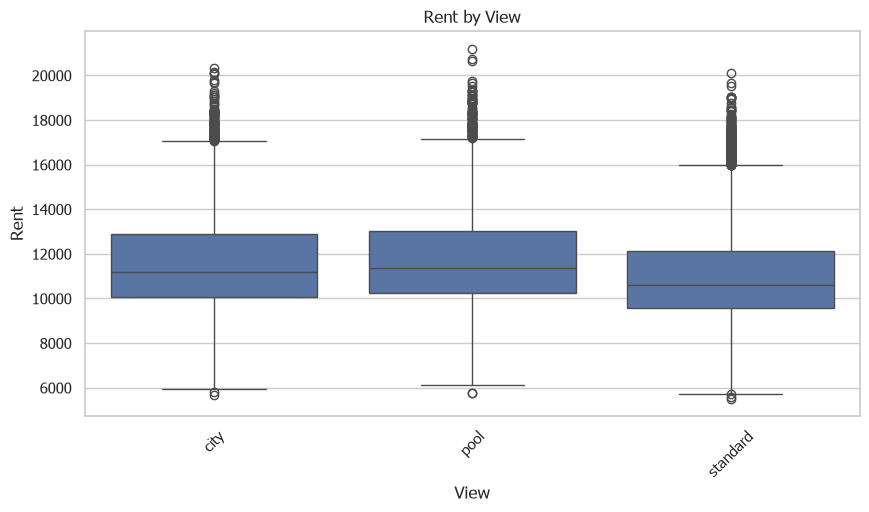

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_data, x="view", y="rent")
plt.title("Rent by View")
plt.xlabel("View")
plt.ylabel("Rent")
plt.xticks(rotation=45)
plt.show()

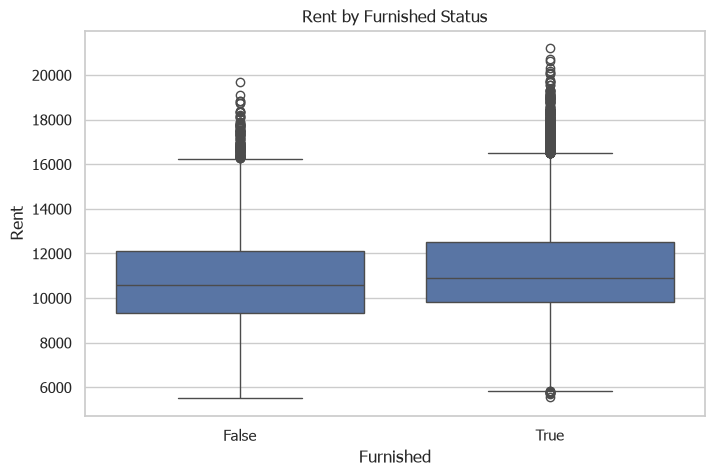

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_data, x="furnished", y="rent")
plt.title("Rent by Furnished Status")
plt.xlabel("Furnished")
plt.ylabel("Rent")
plt.show()

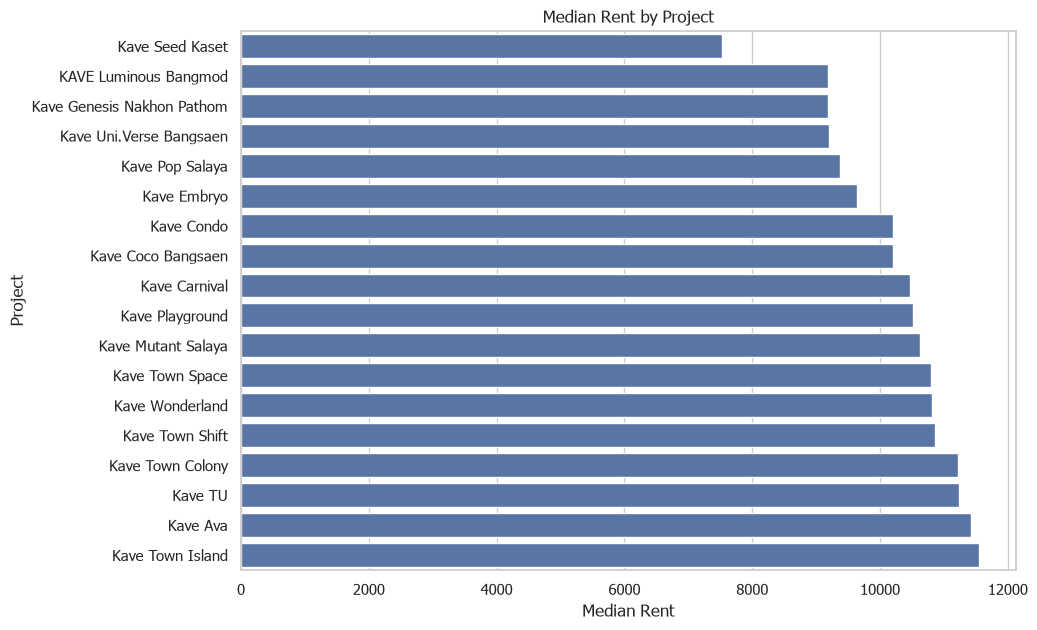

In [21]:
project_rent = (
    eda_data.groupby("project_name")["rent"]
    .median()
    .sort_values()
    .reset_index()
)

plt.figure(figsize=(10, 7))
sns.barplot(data=project_rent, x="rent", y="project_name")
plt.title("Median Rent by Project")
plt.xlabel("Median Rent")
plt.ylabel("Project")
plt.show()

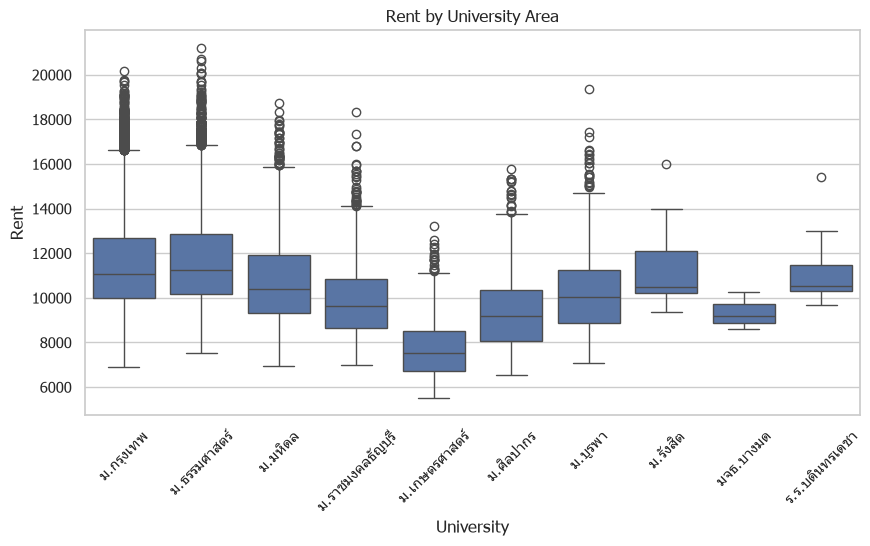

In [22]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_data, x="university", y="rent")
plt.title("Rent by University Area")
plt.xlabel("University")
plt.ylabel("Rent")
plt.xticks(rotation=45)
plt.show()

กราฟแสดงความสัมพันธ์เบื้องต้นเท่านั้น ยังสรุปไม่ได้ว่าตัวแปรใดเป็นสาเหตุของราคา และควรตรวจจำนวนข้อมูลในแต่ละกลุ่มร่วมด้วย

## 7. ดูแนวโน้มราคาตามเวลา

แปลง `date_start` ให้เป็นข้อมูลวันที่ แล้วคำนวณค่ามัธยฐานของราคาในแต่ละเดือน

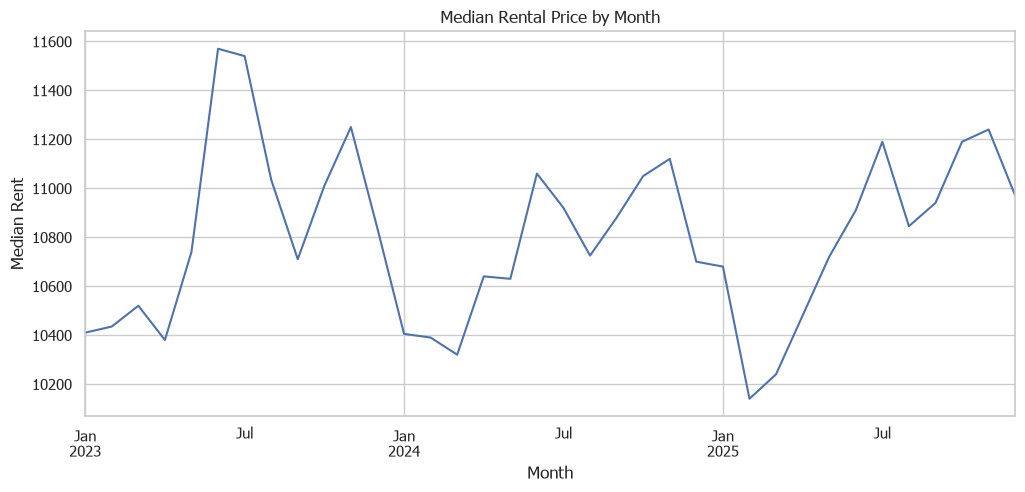

In [23]:
eda_data["start_month"] = eda_data["date_start"].dt.to_period("M").dt.to_timestamp()

monthly_rent = eda_data.groupby("start_month")["rent"].median()

plt.figure(figsize=(12, 5))
monthly_rent.plot()
plt.title("Median Rental Price by Month")
plt.xlabel("Month")
plt.ylabel("Median Rent")
plt.show()

## 8. ตรวจสอบผลการแบ่งข้อมูลตามเวลา

แบ่งข้อมูลโดยใช้วันที่เริ่มสัญญา เพื่อให้โมเดลเรียนรู้จากอดีตและประเมินกับข้อมูลที่เกิดขึ้นภายหลัง

- Train: ถึงวันที่ 31 ธันวาคม 2025
- Validation: 1 มกราคม ถึง 31 มีนาคม 2026
- Test: หลังวันที่ 31 มีนาคม 2026

In [24]:
train, validation, test = chronological_split(
    rental_data,
    date_column="date_start",
)

print("Train:", len(train), "แถว")
print("Validation:", len(validation), "แถว")
print("Test:", len(test), "แถว")

print("\nช่วงวันที่ของ Train:", train["date_start"].min(), "ถึง", train["date_start"].max())
print("ช่วงวันที่ของ Validation:", validation["date_start"].min(), "ถึง", validation["date_start"].max())
print("ช่วงวันที่ของ Test:", test["date_start"].min(), "ถึง", test["date_start"].max())

Train: 40580 แถว
Validation: 3120 แถว
Test: 7265 แถว

ช่วงวันที่ของ Train: 2023-01-03 00:00:00 ถึง 2025-12-30 00:00:00
ช่วงวันที่ของ Validation: 2026-01-06 00:00:00 ถึง 2026-03-31 00:00:00
ช่วงวันที่ของ Test: 2026-04-07 00:00:00 ถึง 2026-06-23 00:00:00


## 9. สรุปผล EDA

หลังจากรันทุก Cell ให้เขียนสรุปด้วยภาษาของตัวเอง โดยตอบคำถามต่อไปนี้:

1. ข้อมูลมี Missing Value หรือข้อมูลซ้ำหรือไม่
> ไม่มี
2. ราคาค่าเช่าส่วนใหญ่อยู่ในช่วงใด
> 11119.396645
3. พบราคาที่อาจเป็น Outlier หรือไม่
> 165-21500
4. ประเภทห้องและขนาดห้องสัมพันธ์กับราคาอย่างไร
> ประเภทห้องมีคสพ.กับราคาเช่า เมื่อห้องที่ใหญกว่าจะมีแนวโน้มราคาเช่าสูงกว่า ขนาดห้องมีคสพ.กับราคาเช่า เมื่อขนาดห้องใหญ่ขึ้นส่งผลให้ราคาเช่าสูงขึ้น ซึ่งราคาเช่าก็ขึ้นอยู่กับสิ่งอื่นๆอีกด้วย
5. สัญญาใหม่และสัญญาต่ออายุมีราคาแตกต่างกันหรือไม่
> ราคาเฉลี่ยไม่ค่อยต่างกันมาก โดยผู้เช่าเดิมต่อสัญญาจะมีราคาเฉลี่ยสูงกว่าสัญญาใหม่เล็กน้อย
6. ราคามีการเปลี่ยนแปลงตามเวลาหรือไม่
> ราคามีการเปลี่ยนแปลงเล็กน้อยในแต่ละเดือน โดยค่ามัธยฐานอยู่ประมาณ 10,140–11,570 บาท แต่ยังไม่พบแนวโน้มเพิ่มขึ้นหรือลดลงอย่างชัดเจน
7. Feature ใดควรนำไปทดลองสร้างโมเดล
> ควรทดลองใช้ size_sqm, room_type, project_name, distance_to_campus_m, view, furnished, facility_count, floor, is_renewal, lease_months และเดือนที่เริ่มสัญญา เพราะเป็นข้อมูลที่อาจสัมพันธ์กับราคาและทราบก่อนทำนาย
8. ตัวแปรตัวเลขใดมี Correlation กับราคาค่าเช่ามากที่สุด
> size_sqm มี Correlation กับราคามากที่สุดที่ 0.65 รองลงมาคือ distance_to_campus_m ที่ -0.32 และ facility_count ที่ 0.15 ส่วน floor และ lease_months มีความสัมพันธ์เชิงเส้นค่อนข้างต่ำ
9. `view`, `furnished`, `project_name` และ `university` มีความสัมพันธ์กับราคาอย่างไร
> ห้องวิวสระและวิวเมืองมีราคาสูงกว่าวิวทั่วไปเล็กน้อย ห้องมีเฟอร์นิเจอร์มีราคาสูงกว่าห้องไม่มีเฟอร์นิเจอร์ และราคาแตกต่างกันชัดเจนตามโครงการและพื้นที่มหาวิทยาลัย จึงควรทดลองนำตัวแปรเหล่านี้ไปใช้ในโมเดลครับ

> หมายเหตุ: Notebook นี้ยังไม่รวม `weekly_market` เพราะการรวมข้อมูลรายสัปดาห์ต้องกำหนดเวลาอ้างอิงให้ชัดเจน เพื่อป้องกันการนำข้อมูลอนาคตมาใช้โดยไม่ตั้งใจ

# ส่วนที่ 2: การฝึกและประเมินโมเดลพยากรณ์ราคาเช่า

ส่วนนี้ใช้ผลจากโมเดลที่ฝึกด้วยไฟล์ `train_rental_price.py` โดยเปรียบเทียบ
2 โมเดลตามเอกสารอ้างอิงของโครงงาน:

1. **Forward/Stepwise Multiple Linear Regression** — ใช้อธิบายปัจจัยที่สัมพันธ์กับราคา
2. **Gradient Boosting Regressor** — ใช้เรียนรู้ความสัมพันธ์ที่ไม่เป็นเส้นตรง

> Notebook นี้โหลดโมเดลและผลการจูนที่บันทึกไว้แล้ว จึงไม่ฝึก Gradient Boosting
> ใหม่ทุกครั้ง หากต้องการฝึกใหม่ให้รัน
> `.venv\Scripts\python.exe -m kaverentai.models.train_rental_price`

## 10. โหลดผลการฝึกโมเดล

กำหนดตำแหน่งไฟล์ให้รองรับทั้งการเปิด Notebook จากโฟลเดอร์โปรเจกต์
และจากโฟลเดอร์ `notebooks` จากนั้นโหลดข้อมูล โมเดล และผลการประเมิน

In [25]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from kaverentai.data.split_data import chronological_split
from kaverentai.features.rental_price_features import (
    DATE_COLUMN,
    build_rental_price_features,
    split_features_and_target,
)
from kaverentai.recommendation.price_engine import recommend_rental_price

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_DIR = PROJECT_ROOT / "models" / "rental_price"
REPORT_DIR = PROJECT_ROOT / "reports"

STEPWISE_MODEL_PATH = MODEL_DIR / "rental_price_stepwise_mlr.joblib"
GRADIENT_BOOSTING_MODEL_PATH = (
    MODEL_DIR / "rental_price_gradient_boosting.joblib"
)
WINNER_MODEL_PATH = PROJECT_ROOT / "models" / "rental_price_model.joblib"

required_files = [
    STEPWISE_MODEL_PATH,
    GRADIENT_BOOSTING_MODEL_PATH,
    WINNER_MODEL_PATH,
]
missing_files = [path for path in required_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError(f"ไม่พบไฟล์โมเดล: {missing_files}")

stepwise_model = joblib.load(STEPWISE_MODEL_PATH)
gradient_boosting_model = joblib.load(GRADIENT_BOOSTING_MODEL_PATH)
winner_model = joblib.load(WINNER_MODEL_PATH)

modeling_data = build_rental_price_features()
train_data, validation_data, test_data = chronological_split(
    modeling_data,
    date_column=DATE_COLUMN,
)

X_validation, y_validation = split_features_and_target(validation_data)
X_test, y_test = split_features_and_target(test_data)

print("โมเดลผู้ชนะ:", type(winner_model.named_steps["model"]).__name__)
print("Train:", len(train_data), "แถว")
print("Validation:", len(validation_data), "แถว")
print("Test:", len(test_data), "แถว")

โมเดลผู้ชนะ: GradientBoostingRegressor
Train: 40580 แถว
Validation: 3120 แถว
Test: 7265 แถว


## 11. Rolling Time Validation

การเลือก Feature และการจูนพารามิเตอร์ใช้ข้อมูลภายใน Train เท่านั้น
โดยฝึกจากอดีตและตรวจสอบกับไตรมาสถัดไปทั้งหมด 4 รอบ

```text
อดีตถึง ธ.ค. 2024  → ตรวจสอบ ม.ค.–มี.ค. 2025
อดีตถึง มี.ค. 2025 → ตรวจสอบ เม.ย.–มิ.ย. 2025
อดีตถึง มิ.ย. 2025 → ตรวจสอบ ก.ค.–ก.ย. 2025
อดีตถึง ก.ย. 2025  → ตรวจสอบ ต.ค.–ธ.ค. 2025
```

Validation หลักช่วงมกราคม–มีนาคม 2026 ยังไม่ถูกใช้ในขั้นจูน
และ Test ช่วงเมษายน–มิถุนายน 2026 ใช้ประเมินหลังเลือกโมเดลแล้วเท่านั้น

In [26]:
metadata_path = MODEL_DIR / "rental_price_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

rolling_folds = pd.DataFrame(metadata["rolling_folds"])
rolling_folds = rolling_folds.rename(
    columns={
        "name": "fold",
        "train_end": "train_end",
        "validation_end": "validation_end",
        "train_rows": "train_rows",
        "validation_rows": "validation_rows",
    }
)
display(rolling_folds)

,fold,train_end,validation_end,train_rows,validation_rows
0,2025_Q1,2024-12-31,2025-03-31,23898,2546
1,2025_Q2,2025-03-31,2025-06-30,26444,6614
2,2025_Q3,2025-06-30,2025-09-30,33058,3001
3,2025_Q4,2025-09-30,2025-12-31,36059,4521


## 12. ผลการเลือก Feature ของ Stepwise Regression

Forward Selection ทดลองเพิ่ม Feature ทีละกลุ่ม และใช้ **Rolling MAE เฉลี่ย**
เป็นเกณฑ์ เมื่อ Feature ถัดไปช่วยลด MAE น้อยกว่า 1 บาทจึงหยุด

In [27]:
stepwise_history = pd.read_csv(
    REPORT_DIR / "tables" / "rental_price_stepwise_history.csv"
)

selected_feature_table = stepwise_history[
    [
        "step",
        "added_feature",
        "mean_rolling_mae",
        "std_rolling_mae",
        "mae_improvement",
    ]
].round(2)

display(selected_feature_table)
print("Feature ที่เลือก:", metadata["stepwise_selected_features"])

,step,added_feature,mean_rolling_mae,std_rolling_mae,mae_improvement
0,1,room_type,1209.77,187.04,NaN
1,2,project_name,1037.64,121.99,172.13
2,3,start_month,969.80,127.85,67.83
3,4,view,941.30,139.48,28.50
4,5,is_renewal,921.30,147.08,20.01
5,6,furnished,904.69,139.16,16.61
6,7,floor,902.40,140.33,2.29


Feature ที่เลือก: ['room_type', 'project_name', 'start_month', 'view', 'is_renewal', 'furnished', 'floor']


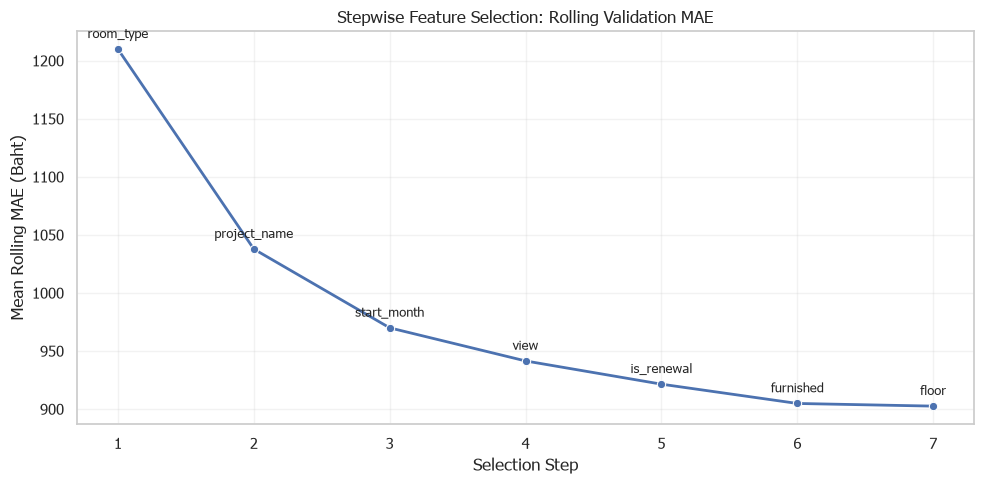

In [28]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=stepwise_history,
    x="step",
    y="mean_rolling_mae",
    marker="o",
    linewidth=2,
)

for row in stepwise_history.itertuples():
    plt.annotate(
        row.added_feature,
        (row.step, row.mean_rolling_mae),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )

plt.title("Stepwise Feature Selection: Rolling Validation MAE")
plt.xlabel("Selection Step")
plt.ylabel("Mean Rolling MAE (Baht)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 13. ผลการจูน Gradient Boosting

ทดลองพารามิเตอร์ 12 ชุดใน Rolling Validation 4 Fold รวม 48 การประเมิน
ชุดที่มี MAE เฉลี่ยต่ำที่สุดเป็นค่าที่นำไปฝึกโมเดลรอบสุดท้าย

In [29]:
tuning_results = pd.read_csv(
    REPORT_DIR / "tables" / "rental_price_gradient_boosting_tuning.csv"
)

tuning_columns = [
    "set_number",
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_samples_leaf",
    "subsample",
    "mean_validation_mae",
    "std_validation_mae",
    "mae_gap",
]

display(
    tuning_results[tuning_columns]
    .sort_values("mean_validation_mae")
    .round(2)
    .reset_index(drop=True)
)

print("ค่าที่เลือก:")
display(pd.Series(metadata["gradient_boosting_params"]).to_frame("value"))

,set_number,n_estimators,learning_rate,max_depth,min_samples_leaf,subsample,mean_validation_mae,std_validation_mae,mae_gap
0,10,350,0.03,4,15,0.9,860.59,124.13,163.38
1,12,450,0.02,4,25,0.8,861.56,120.26,155.88
2,3,450,0.03,3,15,0.9,865.36,127.14,144.58
3,1,350,0.03,3,15,0.9,874.73,123.74,139.84
4,11,350,0.03,3,25,0.8,875.15,122.06,140.57
5,5,450,0.02,3,15,0.9,882.21,120.84,136.42
6,7,350,0.05,2,10,0.9,883.92,125.24,130.95
7,2,250,0.03,3,15,0.9,891.74,119.89,131.86
8,4,350,0.02,3,15,0.9,897.43,117.74,130.90
9,6,250,0.05,2,10,1.0,899.43,121.71,125.09


ค่าที่เลือก:


,value
n_estimators,350.00
learning_rate,0.03
max_depth,4.00
min_samples_leaf,15.00
subsample,0.90


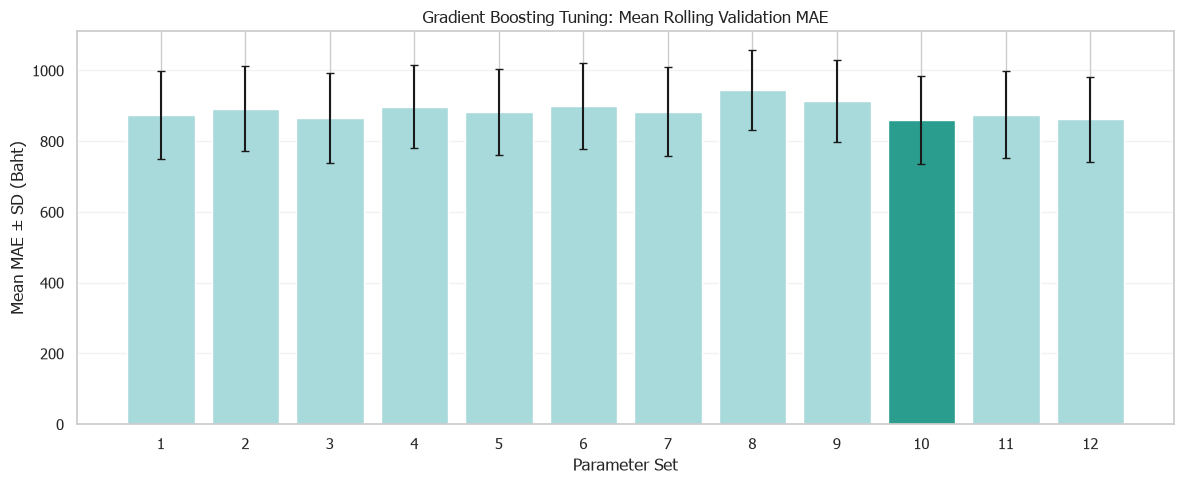

In [30]:
best_tuning_index = tuning_results["mean_validation_mae"].idxmin()
bar_colors = [
    "#2a9d8f" if index == best_tuning_index else "#a8dadc"
    for index in tuning_results.index
]

plt.figure(figsize=(12, 5))
plt.bar(
    tuning_results["set_number"].astype(str),
    tuning_results["mean_validation_mae"],
    yerr=tuning_results["std_validation_mae"],
    color=bar_colors,
    capsize=3,
)
plt.title("Gradient Boosting Tuning: Mean Rolling Validation MAE")
plt.xlabel("Parameter Set")
plt.ylabel("Mean MAE ± SD (Baht)")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 14. เปรียบเทียบประสิทธิภาพของโมเดล

- **MAE** แสดงจำนวนบาทที่พยากรณ์คลาดเคลื่อนโดยเฉลี่ย ค่ายิ่งต่ำยิ่งดี
- **RMSE** ให้น้ำหนักกับข้อผิดพลาดขนาดใหญ่มากขึ้น ค่ายิ่งต่ำยิ่งดี
- **R²** แสดงสัดส่วนความแปรปรวนของราคาที่โมเดลอธิบายได้ ค่ายิ่งสูงยิ่งดี

In [31]:
metrics = pd.read_csv(
    REPORT_DIR / "metrics" / "rental_price_model_metrics.csv"
)

metrics_display = metrics.copy()
metrics_display[["mae", "rmse"]] = metrics_display[["mae", "rmse"]].round(2)
metrics_display["r2"] = metrics_display["r2"].round(4)
display(metrics_display)

,model,split,mae,rmse,r2
0,Stepwise MLR,validation,770.84,1051.46,0.7186
1,Gradient Boosting,validation,759.60,1021.25,0.7345
2,Stepwise MLR,test,1113.72,1395.80,0.5854
3,Gradient Boosting,test,1032.37,1314.12,0.6325


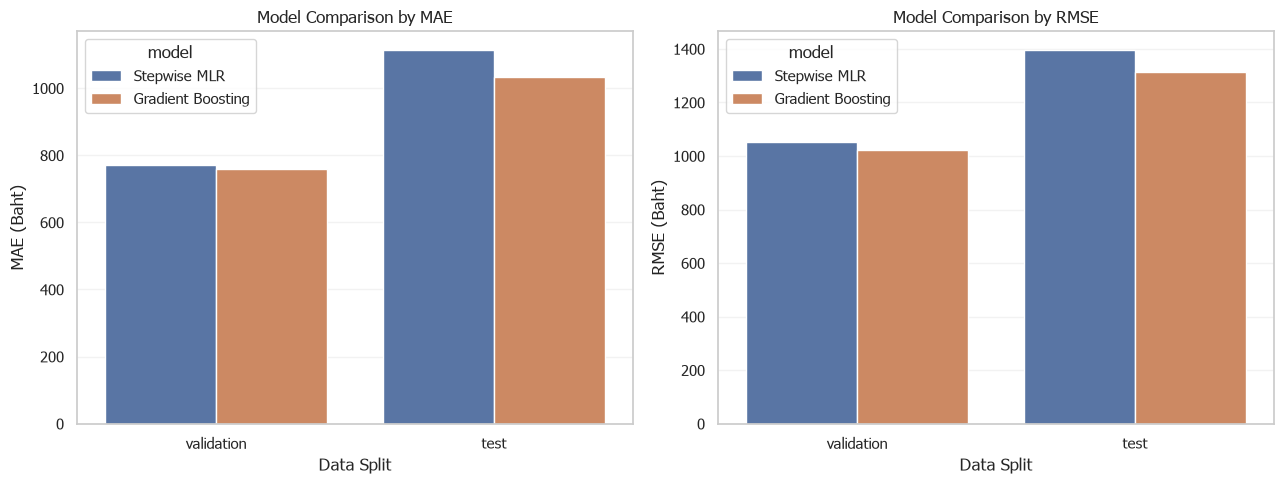

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(
    data=metrics,
    x="split",
    y="mae",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("Model Comparison by MAE")
axes[0].set_xlabel("Data Split")
axes[0].set_ylabel("MAE (Baht)")

sns.barplot(
    data=metrics,
    x="split",
    y="rmse",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("Model Comparison by RMSE")
axes[1].set_xlabel("Data Split")
axes[1].set_ylabel("RMSE (Baht)")

for axis in axes:
    axis.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 15. ราคาจริงเทียบกับราคาที่โมเดลพยากรณ์

จุดที่อยู่ใกล้เส้นประหมายถึงโมเดลพยากรณ์ใกล้เคียงราคาจริง
กราฟนี้ใช้ Test set ซึ่งไม่ถูกใช้ฝึกหรือจูนพารามิเตอร์

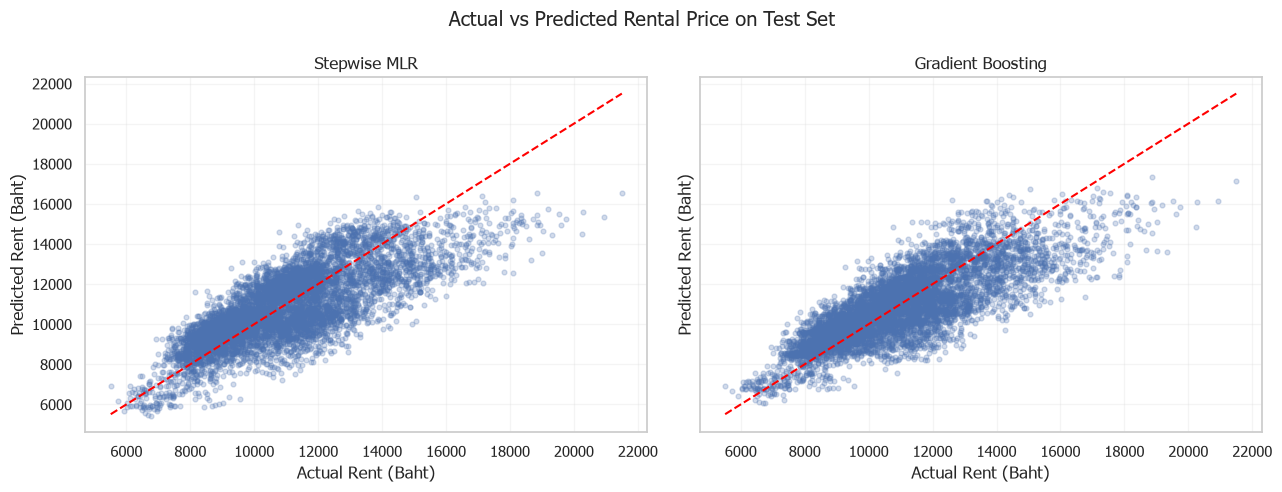

In [33]:
test_predictions = {
    "Stepwise MLR": stepwise_model.predict(X_test),
    "Gradient Boosting": gradient_boosting_model.predict(X_test),
}

minimum_rent = float(y_test.min())
maximum_rent = float(y_test.max())

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)

for axis, (model_name, predictions) in zip(axes, test_predictions.items()):
    axis.scatter(y_test, predictions, alpha=0.25, s=12)
    axis.plot(
        [minimum_rent, maximum_rent],
        [minimum_rent, maximum_rent],
        linestyle="--",
        color="red",
    )
    axis.set_title(model_name)
    axis.set_xlabel("Actual Rent (Baht)")
    axis.set_ylabel("Predicted Rent (Baht)")
    axis.grid(alpha=0.2)

plt.suptitle("Actual vs Predicted Rental Price on Test Set")
plt.tight_layout()
plt.show()

## 16. การกระจายของข้อผิดพลาด

Residual คำนวณจาก `ราคาจริง - ราคาพยากรณ์` ค่าที่ใกล้ศูนย์หมายถึง
พยากรณ์ได้ใกล้เคียงราคาจริง ค่าบวกหมายถึงพยากรณ์ต่ำกว่าราคาจริง
และค่าลบหมายถึงพยากรณ์สูงกว่าราคาจริง

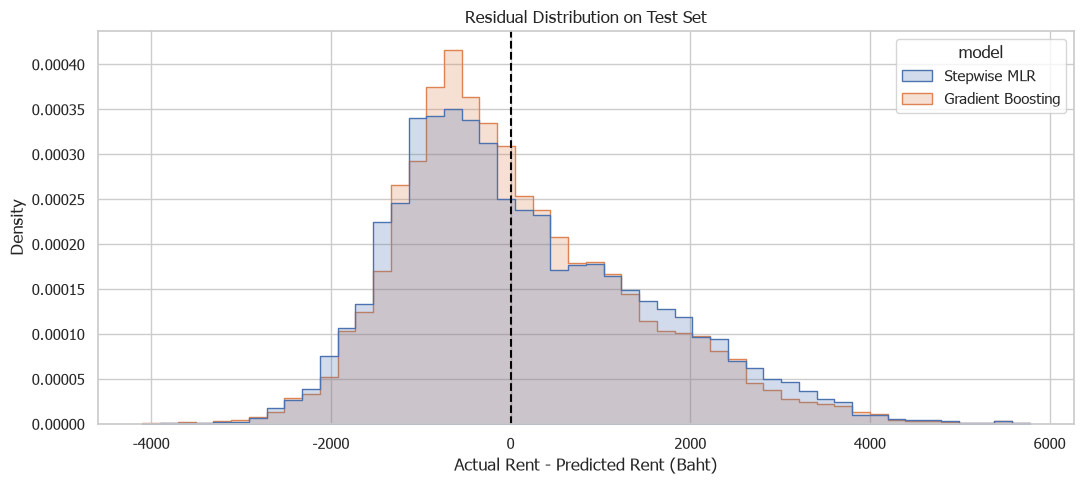

In [34]:
residual_rows = []

for model_name, predictions in test_predictions.items():
    residual_rows.append(
        pd.DataFrame(
            {
                "model": model_name,
                "residual": y_test.to_numpy() - predictions,
            }
        )
    )

residual_data = pd.concat(residual_rows, ignore_index=True)

plt.figure(figsize=(11, 5))
sns.histplot(
    data=residual_data,
    x="residual",
    hue="model",
    bins=50,
    element="step",
    stat="density",
    common_norm=False,
)
plt.axvline(0, linestyle="--", color="black")
plt.title("Residual Distribution on Test Set")
plt.xlabel("Actual Rent - Predicted Rent (Baht)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

## 17. อธิบายผลของโมเดล

Stepwise Regression ใช้ค่าสัมประสิทธิ์เพื่ออธิบายทิศทางความสัมพันธ์
ส่วน Gradient Boosting ใช้ Feature Importance เพื่อแสดงว่า Feature ใด
ถูกใช้ช่วยลดข้อผิดพลาดในการสร้างต้นไม้มากที่สุด

> Feature Importance แสดงความสำคัญต่อการพยากรณ์ แต่ไม่ใช่หลักฐานว่า
> Feature นั้นเป็นสาเหตุของราคาโดยตรง

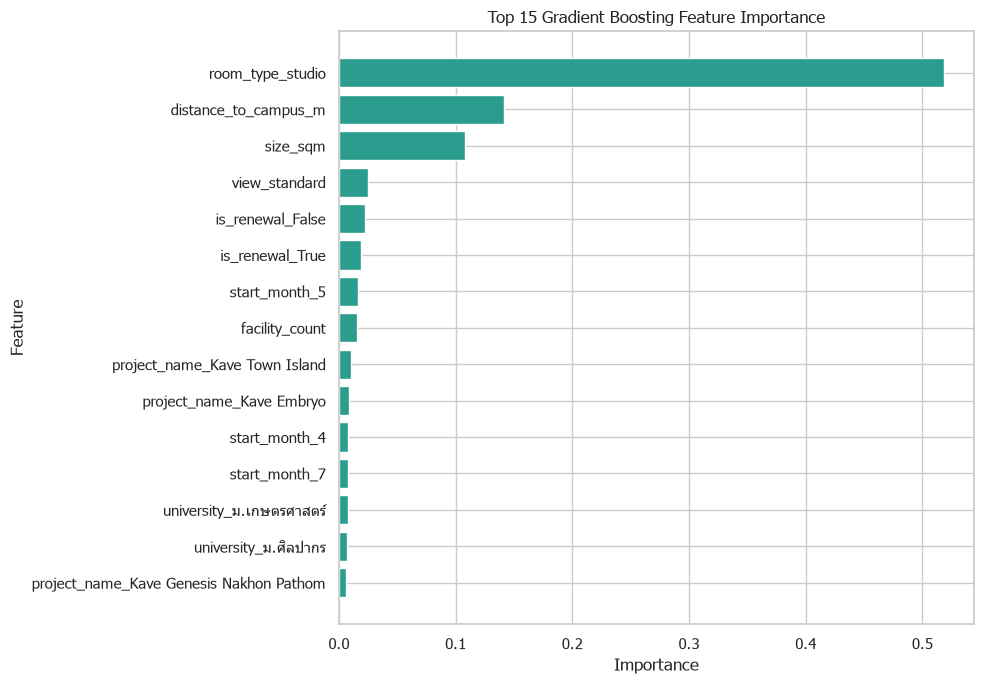

In [35]:
importance = pd.read_csv(
    REPORT_DIR / "tables" / "rental_price_gradient_boosting_importance.csv"
)
importance["feature"] = (
    importance["feature"]
    .str.replace("category__", "", regex=False)
    .str.replace("number__", "", regex=False)
)
top_importance = importance.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_importance["feature"],
    top_importance["importance"],
    color="#2a9d8f",
)
plt.title("Top 15 Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

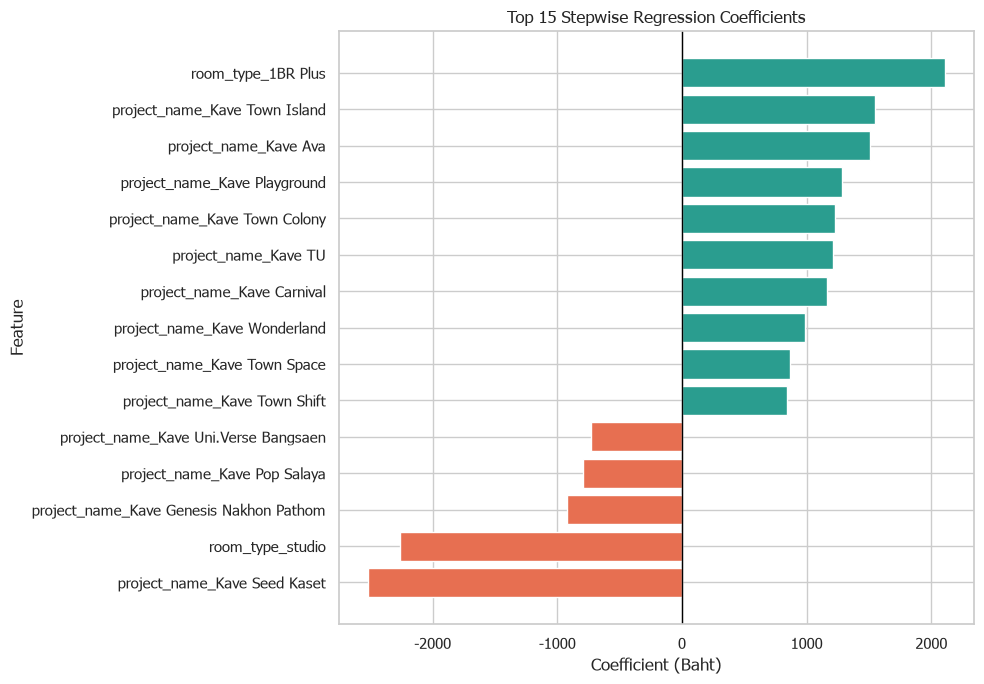

In [36]:
coefficients = pd.read_csv(
    REPORT_DIR / "tables" / "rental_price_stepwise_coefficients.csv"
)
coefficients = coefficients.loc[coefficients["feature"] != "intercept"].copy()
coefficients["feature"] = (
    coefficients["feature"]
    .str.replace("category__", "", regex=False)
    .str.replace("number__", "", regex=False)
)
top_coefficients = coefficients.nlargest(15, "absolute_coefficient")
top_coefficients = top_coefficients.sort_values("coefficient")
coefficient_colors = [
    "#e76f51" if value < 0 else "#2a9d8f"
    for value in top_coefficients["coefficient"]
]

plt.figure(figsize=(10, 7))
plt.barh(
    top_coefficients["feature"],
    top_coefficients["coefficient"],
    color=coefficient_colors,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 15 Stepwise Regression Coefficients")
plt.xlabel("Coefficient (Baht)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 18. ตัวอย่างการนำโมเดลไปใช้งาน

ตัวอย่างนี้นำรายละเอียดห้องหนึ่งรายการจาก Test set ส่งให้ Price Engine
แล้วแสดงราคาเช่าที่โมเดลแนะนำ เปรียบเทียบกับราคาเช่าจริง

In [37]:
sample_position = len(test_data) // 2
sample_features = X_test.iloc[sample_position].to_dict()
sample_features["date_start"] = test_data.iloc[sample_position][DATE_COLUMN]

sample_result = recommend_rental_price(
    sample_features,
    model_path=WINNER_MODEL_PATH,
)
actual_rent = float(y_test.iloc[sample_position])

room_summary_columns = [
    "project_name",
    "room_type",
    "size_sqm",
    "floor",
    "view",
    "furnished",
    "lease_months",
    "is_renewal",
    "date_start",
]
room_summary = pd.Series(
    {column: sample_features[column] for column in room_summary_columns},
    name="value",
)

prediction_summary = pd.DataFrame(
    {
        "รายการ": [
            "ราคาเช่าจริง",
            "ราคาที่โมเดลพยากรณ์",
            "ความคลาดเคลื่อนสัมบูรณ์",
        ],
        "บาทต่อเดือน": [
            round(actual_rent),
            sample_result["recommended_rent"],
            round(abs(actual_rent - sample_result["predicted_rent"])),
        ],
    }
)

display(room_summary.to_frame())
display(prediction_summary)

,value
project_name,Kave Condo
room_type,1BR
size_sqm,32.1
floor,1
view,pool
furnished,True
lease_months,12
is_renewal,False
date_start,2026-05-12 00:00:00


,รายการ,บาทต่อเดือน
0,ราคาเช่าจริง,10800
1,ราคาที่โมเดลพยากรณ์,11793
2,ความคลาดเคลื่อนสัมบูรณ์,993


## 19. สรุปผลสำหรับใช้เขียนรายงาน

โครงงานเปรียบเทียบ Forward/Stepwise Multiple Linear Regression และ
Gradient Boosting Regressor โดยแบ่งข้อมูลตามลำดับเวลาเพื่อป้องกันข้อมูล
อนาคตรั่วไหลเข้าสู่การฝึกโมเดล การเลือก Feature และการจูนพารามิเตอร์
ดำเนินการด้วย Rolling Time Validation จำนวน 4 Fold ภายในชุด Train

Gradient Boosting ชุดที่ดีที่สุดประกอบด้วย `n_estimators=350`,
`learning_rate=0.03`, `max_depth=4`, `min_samples_leaf=15` และ
`subsample=0.9` โดยมี Rolling Validation MAE เฉลี่ย 860.59 บาท

ผลการประเมิน Validation หลักพบว่า Gradient Boosting มี MAE 759.60 บาท
ต่ำกว่า Stepwise Regression ซึ่งมี MAE 770.84 บาท จึงเลือก Gradient
Boosting เป็นโมเดลหลัก ผล Test ยังสอดคล้องกัน โดย Gradient Boosting มี
MAE 1,032.37 บาท และ R² 0.6325 ขณะที่ Stepwise Regression มี MAE
1,113.72 บาท และ R² 0.5854

ผล Test ที่ด้อยกว่า Validation สะท้อนว่ารูปแบบราคามีการเปลี่ยนแปลงตามเวลา
จึงควรระบุเป็นข้อจำกัด และควรฝึกโมเดลใหม่เมื่อมีข้อมูลจริงในช่วงเวลาล่าสุด

## 20. เอกสารอ้างอิงของโมเดล

- งานเรื่องแบบจำลองพยากรณ์อัตราค่าเช่าที่อยู่อาศัยโดยรอบ
  มหาวิทยาลัยธรรมศาสตร์ ศูนย์รังสิต ใช้อ้างอิงแนวทาง Stepwise Multiple
  Linear Regression
- Hernes, M., Tutak, M., & Siewiera, A. (2024). *Prediction of residential
  real estate price on primary market using machine learning*.
  Procedia Computer Science, 246, 3142–3147.
  DOI: 10.1016/j.procs.2024.09.358 ใช้อ้างอิง Gradient Boosting